## Port accessibility - terminal congestion (jetty)
In this notebook, we set up a basic simulation in which two vessels are bound for the same terminal in a port. The terminal consists of a single jetty. At the jetty, the vessels berth, unload cargo, and deberth, after they sail back to sea. We examine terminal congestion and consider berth occupation from the terminal's point-of-view.

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
from pyproj import Geod
from shapely.geometry import Point, LineString

# package(s) related to the hydrodynamics and tidal windows
import xarray as xr

# load OpenTNSim core mixins
from opentnsim.core import Identifiable, Movable, VesselProperties

# load OpenTNSim environment mixin to add hydrodynamic data to the environment
from opentnsim.environment.mixins.hydrodynamics import HydrodynamicData

# load OpenTNSim graph utils
from opentnsim.graph.calculations import calculate_distance_along_path
from opentnsim.graph.visualizations import plot_graph

# load OpenTNSim port module mixins and utils
from opentnsim.port.mixins.tidal_accessibility import HasDraughtRestrictions
from opentnsim.port.mixins.anchorage_area import IsAnchorage, PassesAnchorage
from opentnsim.port.mixins.port import IsPort, HasPortAccess
from opentnsim.port.mixins.berth import IsJetty
from opentnsim.port.mixins.terminal import IsTerminal, HasTerminal
from opentnsim.port.rule_constructor import vessel_characteristics, vessel_direction
from opentnsim.port.tidal_window_constructor import (
    vessel_specifications,
    vertical_tidal_window_specifications,
    vertical_tidal_window_input,
    NetworkProperties
)

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# package(s) needed for inspecting the output
import pandas as pd
import numpy as np

# package(s) for plotting
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.2.2.dev105+gc0ed3023c.d20260415


#### Define input
vessel

In [2]:
vessel_length = 200
vessel_beam = 40
vessel_draught = 12
vessel_speed = 4.5 #m/s
vessel_loading_time = 6 #hours

infrastructure

In [3]:
waterway_length = 30000 #meters
waterway_depth = 16.5 #meters (NGD: nautical guaranteed depth = MBL: maintained bed level)

harbour_basin_depth = 16.5
anchorage_area_depth = 17

tide

In [4]:
tidal_period = 12.5 #hours
tidal_range_sea = 2.0 #meters
tidal_propagation_speed = np.sqrt(9.81*waterway_depth) #meters per second (np.sqrt(grav_acc*waterway_depth)), grav_acc=9.81
tidal_amplication = 0.8 #amplification factor

tidal restrictions

In [5]:
#percentage of the draught as UKC (10% of draught is common)
ukc_percentage_sea = 10.0 #% of draught 
ukc_percentage_canal = 10.0 #% of draught

#static value as UKC (0.5 m is common, but not in combination with ukc_percentage)
ukc_static_sea = 0.0 #meters
ukc_static_canal = 0.0 #meters

#freshwater allowance as percentage of draught as additional UKC: saltwater at sea (no sinkage), fresher water in port (5% extra sinkage common)
fwa_sea = 0.0 #% of draught
fwa_canal = 0.0 #% of draught

#### 0. Create environment

In [6]:
# set simulation time
simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
simulation_stop = datetime.datetime(2024, 1, 8, 0, 0, 0)

# create time series aligned with simulation time
timestep = pd.Timedelta(minutes=5)
time_series = pd.date_range(simulation_start,simulation_stop,freq=timestep)

env = simpy.Environment(initial_time=simulation_start.timestamp())
env.simulation_start = simulation_start
env.simulation_stop = simulation_stop
env.epoch = simulation_start

#### 1. Create graph
Next we create a network (a graph) along which the vessel can move. For this case we create a single edge of 100 km exactly.

In [7]:
# initialize geodetic calculator with WGS84 ellipsoid
geod = Geod(ellps="WGS84")

In [8]:
# starting point (longitude, latitude)
coordinates_sea = (0,0)

# compute the other point 100 km East from Point 0
coordinates_port = geod.fwd(coordinates_sea[0], coordinates_sea[1], 90 ,waterway_length) # East from Point 0

# define nodes with their geographic coordinates
coordinates_waterway = {"Sea": (coordinates_sea[0], coordinates_sea[1]),
                        "Port basin": (coordinates_port[0], coordinates_port[1]),}

In [9]:
# create list of edges
edges = [("Sea", "Port basin"), ("Port basin", "Sea")] # bi-directional edge

In [10]:
# create a directed graph
graph = nx.DiGraph()

# add nodes
for name, coordinate in coordinates_waterway.items():
    graph.add_node(name, geometry=Point(coordinate[0], coordinate[1]))

# add edges
for edge in edges:
    graph.add_edge(edge[0], edge[1], geometry=LineString([Point(coordinates_sea),Point(coordinates_port[:-1])]), weight=1, length_m=waterway_length)

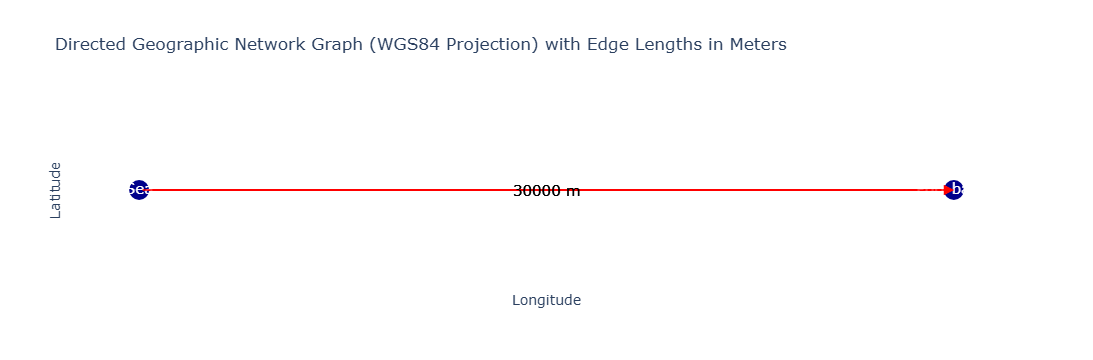

In [11]:
plot_graph(graph)

In [12]:
# add graph to environment
env.graph = graph

#### 1+ Adding environmental data

In [13]:
# create empty hydrodynamic dataset
hydrodynamic_data = xr.Dataset()

In [14]:
tidal_phase_shift = pd.Timedelta(seconds=waterway_length/tidal_propagation_speed)

tidal_water_level_sea = (tidal_range_sea/2)*np.sin(2*np.pi*((time_series-simulation_start)/(12.5*pd.Timedelta(hours=1))))
tidal_water_level_port = tidal_amplication*(tidal_range_sea/2)*np.sin(2*np.pi*((time_series-simulation_start-tidal_phase_shift)/(12.5*pd.Timedelta(hours=1))))

In [15]:
water_level_data = xr.DataArray(data=[tidal_water_level_sea,tidal_water_level_port],coords={'STATION':graph.nodes,'TIME':time_series})
MBLs = waterway_depth*np.ones(len(time_series))
MBL_data = xr.DataArray(data=[MBLs,MBLs],coords={'STATION':graph.nodes,'TIME':time_series})
hydrodynamic_data['Water level'] = water_level_data
hydrodynamic_data['Nautical depth'] = MBL_data

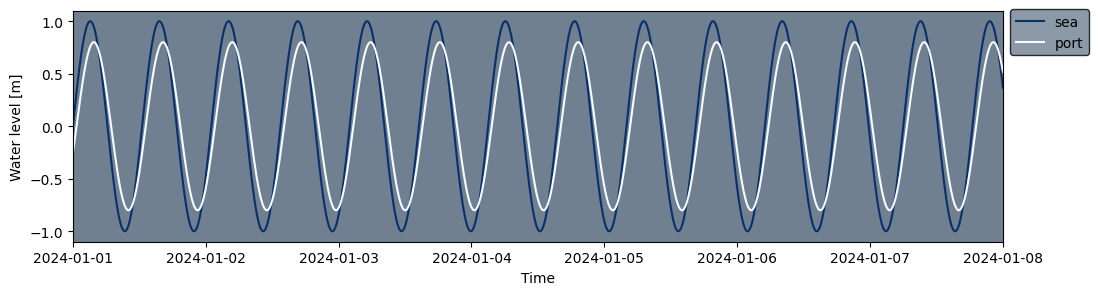

In [16]:
fig,ax = plt.subplots(figsize=[12,3])
ax.set_facecolor('slategrey')
cmap = plt.get_cmap('Blues_r')
ax.plot(time_series,tidal_water_level_sea,color=cmap(0),label='sea')
ax.plot(time_series,tidal_water_level_port,color=cmap(cmap.N),label='port')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel('Time')
ax.set_ylabel('Water level [m]')
ax.set_xlim(time_series[0],time_series[-1])
ax.legend(loc='upper right',frameon=True,bbox_to_anchor=[1.1,1.0375],facecolor='slategray',edgecolor='k');

In [17]:
data = HydrodynamicData(env=env, hydrodynamic_data = hydrodynamic_data)

In [18]:
ukc_p = [ukc_percentage_sea/100,ukc_percentage_canal/100] #percentage of the UKC (10% of draught is common)
ukc_s = [ukc_static_sea,ukc_static_canal] #static value of the UKC
fwa = [fwa_sea/100,fwa_canal/100] #freshwater allowance as percentage of UKC: saltwater at sea (no sinkage), fresher water in port (5% extra sinkage)

network_properties = NetworkProperties()
for index,node in enumerate(graph.nodes):
    graph.nodes[node]['Vertical tidal restriction'] = {}
    vertical_tidal_window_inputs = []

    vessel_specification = vessel_specifications({vessel_characteristics.min_ge_Draught: 0.0},'x',vessel_direction.inbound)
    window_specification = vertical_tidal_window_specifications(ukc_s = ukc_s[index],
                                                                ukc_p = ukc_p[index],
                                                                fwa = fwa[index],)
    
    vertical_tidal_window_inputs.append(vertical_tidal_window_input(vessel_specifications = vessel_specification,
                                                                    window_specifications = window_specification))

    network_properties.append_vertical_tidal_restriction_to_network(env.graph,node,vertical_tidal_window_inputs)

#### 1+ Adding infrastructure

In [19]:
port = IsPort(env=env, name = "Port", port_entry_nodes=['Sea'])

In [20]:
anchorage = IsAnchorage(env=env, capacity=20, name = 'Anchorage', node = 'Sea', depth = anchorage_area_depth, geometry=env.graph.nodes['Sea']['geometry'], port = port)

In [21]:
jetty = IsJetty(env=env, length=250, depth=harbour_basin_depth, name='Jetty',node='Port basin')
berths = [jetty]

terminal = IsTerminal(env=env, name = 'Terminal', berths=berths, port = port)

#### 2. Create agents

In [22]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (HasPortAccess,
     HasTerminal,
     PassesAnchorage,
     HasDraughtRestrictions,
     Identifiable, # allows to give the object a name and a random ID,
     Movable,      # allows the object to move, with a fixed speed, while logging this activity
     VesselProperties,
    ), 
    {}
)

In [23]:
def mission(env, vessel, arrival_time = simulation_start):
    """
    Method that defines the mission of the vessel. 
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    if arrival_time < simulation_start:
        raise ValueError("The vessel's arrival time at the port should be later that the simulation start time")
    else:
        delay = (arrival_time - simulation_start).total_seconds()
        yield vessel.env.timeout(delay)
    yield from vessel.move()

In [24]:
def create_vessel(name, route, next_destination, 
                  vessel_speed = 4.5, berthing_time = 15, loading_time = 6, deberthing_time = 5, 
                  vessel_length = vessel_length, vessel_beam = vessel_beam, vessel_draught = vessel_draught):
    data_vessel = {"env": env,                                        # needed for simpy simulation
                   "name": name,                                      # required by Identifiable
                   "geometry": env.graph.nodes[route[0]]['geometry'], # required by Locatable
                   "route": route,                                    # required by Routeable
                   "v": vessel_speed,                                 # required by Movable, 1 m/s to check if the distance is covered in the expected time
                   "bound": 'inbound',
                   "terminal": terminal,
                   "berthing_time":berthing_time, #minutes
                   "loading_time": loading_time, #hours
                   "deberthing_time":deberthing_time, #minutes
                   "next_destination":next_destination,
                   "type":"tanker",
                   "L":vessel_length,
                   "B":vessel_beam,
                   "T":vessel_draught,
                   }
    vessel = Vessel(**data_vessel)
    return vessel

In [25]:
# create vessel from a dict 
route = nx.dijkstra_path(env.graph, "Sea", "Port basin")
vessel_1 = create_vessel("vessel_1", route, "Sea")
vessel_2 = create_vessel("vessel_2", route, "Sea")

# start the simulation
vessel_1.mission = env.process(mission(env, vessel_1))
vessel_2.mission = env.process(mission(env, vessel_2, arrival_time = simulation_start + pd.Timedelta(hours=3)))

env.vessels = [vessel_1, vessel_2]

#### 3. Run simulation

In [26]:
env.run()

#### 4. Inspect output

##### Logbook
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [27]:
# load the logbook data into a dataframe
for vessel in env.vessels:
    df = pd.DataFrame.from_dict(vessel.logbook)
    
    print("'{}' logbook data:".format(vessel.name))  
    print('')
    
    display(df)
    
    if not df.empty:
        trip_distance = calculate_distance_along_path(graph, vessel.route)
        trip_duration = datetime.timedelta.total_seconds(vessel.logbook[-1]['Timestamp'] - vessel.logbook[0]['Timestamp'])
        print("'{}' travelled a distance of {:.1f} meters".format(vessel.name, trip_distance))
        print("'{}' took {:.1f} seconds to arrive at its destination".format(vessel.name, trip_duration)) 
        print("'{}' travelled at an average speed of {:.1f} meters per second".format(vessel.name, trip_distance/trip_duration))
    else:
        print("The port was not accessible for vessel")
    print('')
    print('')

'vessel_1' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node Sea to node Port basin start,2024-01-01 00:00:00.000000,0,POINT (0 0)
1,Sailing from node Sea to node Port basin stop,2024-01-01 01:51:06.666667,30000,POINT (0.2694945852358564 0)
2,Berthing start,2024-01-01 01:51:06.666667,30000,POINT (0.2694945852358564 0)
3,Berthing stop,2024-01-01 02:06:06.666667,30000,POINT (0.2694945852358564 0)
4,Loading start,2024-01-01 02:06:06.666667,30000,POINT (0.2694945852358564 0)
5,Loading stop,2024-01-01 08:06:06.666667,30000,POINT (0.2694945852358564 0)
6,Deberthing start,2024-01-01 08:06:06.666667,30000,POINT (0.2694945852358564 0)
7,Deberthing stop,2024-01-01 08:11:06.666667,30000,POINT (0.2694945852358564 0)
8,Sailing from node Port basin to node Sea start,2024-01-01 08:11:06.666667,30000,POINT (0.2694945852358564 0)
9,Sailing from node Port basin to node Sea stop,2024-01-01 10:02:13.333333,60000,POINT (0 0)


'vessel_1' travelled a distance of 30000.0 meters
'vessel_1' took 36133.3 seconds to arrive at its destination
'vessel_1' travelled at an average speed of 0.8 meters per second


'vessel_2' logbook data:



,Message,Timestamp,Value,Geometry
0,Waiting for Terminal start,2024-01-01 03:00:00.000000,0,POINT (0 0)
1,Waiting for Terminal stop,2024-01-01 06:19:59.999999,0,POINT (0 0)
2,Sailing from node Sea to node Port basin start,2024-01-01 06:19:59.999999,0,POINT (0 0)
3,Sailing from node Sea to node Port basin stop,2024-01-01 08:11:06.666666,30000,POINT (0.2694945852358564 0)
4,Berthing start,2024-01-01 08:11:06.666667,30000,POINT (0.2694945852358564 0)
5,Berthing stop,2024-01-01 08:26:06.666667,30000,POINT (0.2694945852358564 0)
6,Loading start,2024-01-01 08:26:06.666667,30000,POINT (0.2694945852358564 0)
7,Loading stop,2024-01-01 14:26:06.666667,30000,POINT (0.2694945852358564 0)
8,Deberthing start,2024-01-01 14:26:06.666667,30000,POINT (0.2694945852358564 0)
9,Deberthing stop,2024-01-01 14:31:06.666667,30000,POINT (0.2694945852358564 0)


'vessel_2' travelled a distance of 30000.0 meters
'vessel_2' took 48133.3 seconds to arrive at its destination
'vessel_2' travelled at an average speed of 0.6 meters per second




##### Berth output
We can plot the occupancy of berths over time

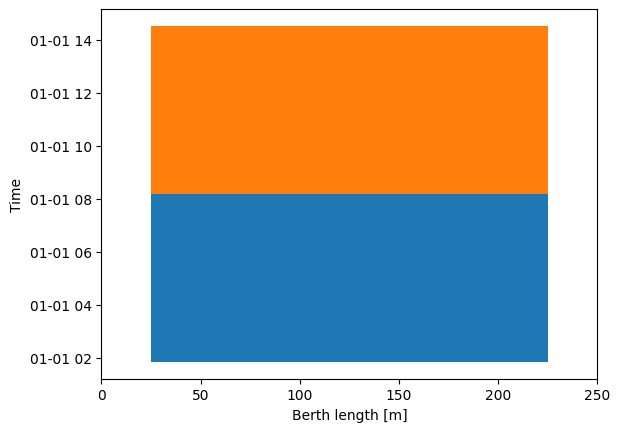

In [28]:
fig = jetty.plot_berth_planning()
fig

We can also get the performance of the berth

In [29]:
berth_performance = jetty.get_berth_performance(time_stop = pd.Timestamp('2024-01-02'))
berth_performance

Total vessels handled                                   2
Average vessel length                               200.0
Shortest service time                     0 days 06:19:45
Vessel_id shortest service time                         1
Average service time                      0 days 06:19:45
Longest service time                      0 days 06:19:45
Vessel_id longest service time                          1
Total service time                        0 days 12:39:30
Berth occupancy (%)                               87.1875
Average waiting time               0 days 01:39:59.999999
Total waiting time                 0 days 03:19:59.999999
Waiting time rate                                0.263331
Causes waiting time                   {'Terminal': 100.0}
dtype: object